In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from pmdarima import auto_arima

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib


Cargar datos.

In [53]:
data = pd.read_csv("../data/raw/10_time_series_sales.csv")
data.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


Convertir la columna fecha a tipo datatime, ordenamos y la usamos como indice

In [54]:
data["date"] = pd.to_datetime(data["date"]) #convierto la columna `date` (que viene como texto) a tipo datetime para poder ordenar, filtrar y usar funciones de series temporales
data = data.sort_values("date").set_index("date") #ordeno los registros en orden cronologico y establezco `date` como índice temporal que es el formato estándar para construir y analizar una serie temporal
data.head()


,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 17:10:08.079328 to 2023-09-03 17:10:08.079328
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


* Tenemos 366 registros
* El indice es un datatime de 1 año
* Variable númerica a predecir "sales"
* No hay valores nulos

#### Construcción y ananálisis de la série temporal

In [56]:
# normalizamos la frecuencia a exactamente 1 día
ts = data["sales"].resample("D").mean()

#si hay Nan rellena con la media
ts = ts.interpolate(method="time")

ts.head()

date
2022-09-03    55.292157
2022-09-04    53.803211
2022-09-05    58.141693
2022-09-06    64.530899
2022-09-07    66.013633
Freq: D, Name: sales, dtype: float64

Buscamos tendencia, posibles patrones repetitivos y cambios de variabilidad

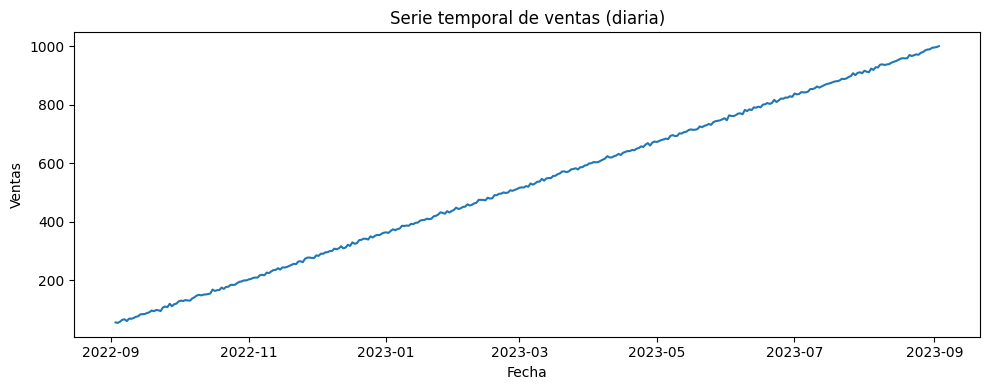

In [57]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title("Serie temporal de ventas (diaria)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()


**¿Cuál es el tensor de la serie temporal?**

Tras normalizar a frecuencia diaria, 1 día.

In [58]:
diffs = ts.index.to_series().diff().dropna()
tensor = diffs.mode().iloc[0]
tensor


Timedelta('1 days 00:00:00')

**¿Cuál es la tendencia y la variabilidad?**

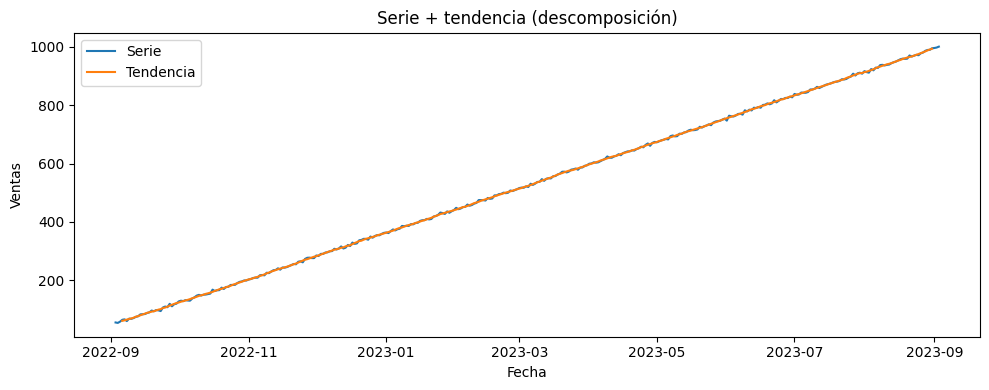

In [59]:
#probamos estacionalidad semanal, perio=7

decomp = seasonal_decompose(ts, model="additive", period=7)

plt.figure(figsize=(10,4))
plt.plot(ts, label="Serie")
plt.plot(decomp.trend, label="Tendencia")
plt.title("Serie + tendencia (descomposición)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


La serie de tiempo tiene una tendencia claramente asccendente.

**¿Es estacionaria?**

Para comprobarlo haremos la prueba de Dickey-Fuller:
- H0: serie estacionaria
- p-value > 0.05 → **no estacionaria**


In [60]:
def test_stationarity(series):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    out = pd.Series(result[0:4],
                    index=["Test Statistic", "p-avalue", "#Lags Used", "Number of Observations Used"])
    for k, v in result[4].items():
        out[f"Critical value({k})"] = v
    return out

adf = test_stationarity(ts)
adf    


Test Statistic                   0.545414
p-avalue                         0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical value(1%)              -3.449065
Critical value(5%)              -2.869786
Critical value(10%)             -2.571163
dtype: float64

Como el p-value es muy superior a 0.05, no podemos rechazar la hipótesis nula del test ADF, por lo que la serie se considera **no estacionaria**.

**¿Existe variabilidad o ruido?**

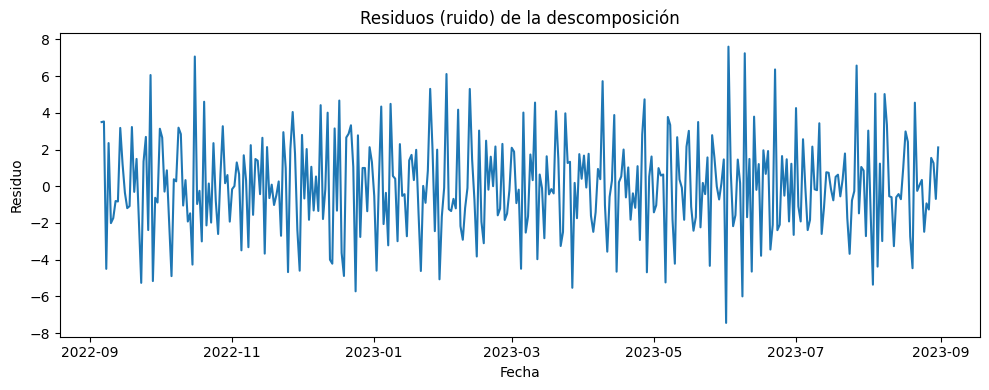

In [61]:
plt.figure(figsize=(10,4))
plt.plot(decomp.resid)
plt.title("Residuos (ruido) de la descomposición")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

**Ruido de la descomposición**

Los residuos oscilan alrededor de "0", sin una tendencia clara → lo que queda tras quitar tendencia/estacionalidad se comporta como “ruido”.
La amplitud se mantiene bastante estable en el tiempo (aprox. entre -5 y +5), con picos puntuales que llegan a ±7/8, lo cual quiere decir que hay una variabilidad moderada y algunos valores atípicos (días especialmente altos/bajos respecto a lo esperado).Por otra parte, noo se aprecia un patrón repetitivo fuerte en los residuos, lo que nos indica una buena señal: el modelo de tendencia está capturando lo principal.


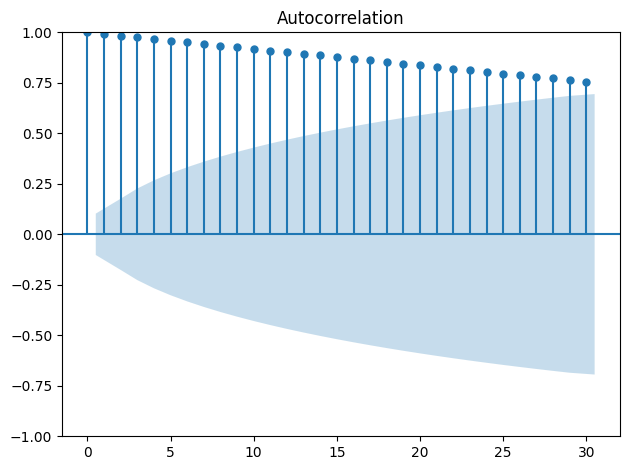

In [62]:
plot_acf(ts.dropna(), lags=30)# ACF: mide la autocorrelación de la serie con sus valores pasados (lags) para ver dependencia temporal/estacionalidad.
plt.tight_layout()
plt.show()


**Autocorrelación (ACF)**

La ACF muestra valores muy altos y positivos en los primeros retardos y un descenso lento hasta el lag 30.  
Esto indica una fuerte dependencia temporal: las ventas de un día están muy relacionadas con las de días anteriores.  
Un decaimiento tan gradual suele ser típico de series con tendencia, por lo que es nrmal que la serie sea no estacionaria.  
Por eso tiene sentido aplicaremos un modelo como **ARIMA**, que aprovecha esta autocorrelación y suele requerir diferenciación (`d > 0`), es decir, modelamos cuanto suben o bajan las ventas respecto al dia anterior.


#### ARIMA

#### Train/test split series temporales

En series temporales no hacemos un split aleatorio, porque rompería el orden del tiempo y “mezclaría” pasado y futuro dando una evaluación irreal.

Por eso hacemos un split temporal:
- **Train (histórico):** se usa para entrenar el modelo con datos del pasado.
- **Test (tramo final):** se reserva como futuro simulado para comprobar si el modelo generaliza y predice bien datos que todavía no ha visto.

In [63]:
"""separamos train/test temporal:
- Train = histórico
- Test = tramo final (simula futuro real)"""

test_size = 60  # últimos 60 días como test
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

train.shape, test.shape, train.index[-1], test.index[0]


((306,),
 (60,),
 Timestamp('2023-07-05 00:00:00'),
 Timestamp('2023-07-06 00:00:00'))


Antes de evaluar ARIMA, usaremos una referencia simple asumiendo que todas las ventas futuras serán iguales al último valor observado en el conjunto de entrenamiento.  
Esto sirve como punto de partida para comprobar si ARIMA realmente mejora el rendimiento.

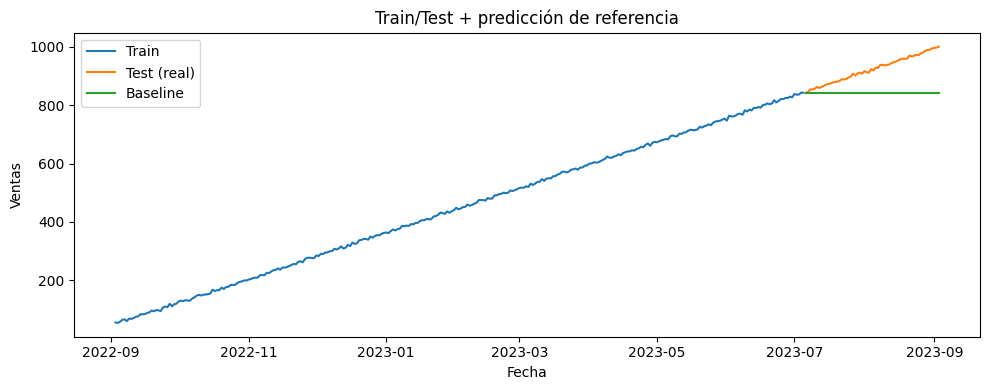

In [64]:
baseline_pred = pd.Series(train.iloc[-1], index=test.index)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test (real)")
plt.plot(baseline_pred, label="Baseline")
plt.title("Train/Test + predicción de referencia")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


In [65]:
mean_absolute_error(test, baseline_pred)

80.14563145518842

In [66]:
rmse(test, baseline_pred)

np.float64(92.12303788409979)

En la gráfica se puede ver que Train muestra una tendencia creciente como ya hemos visto anteriormente.
Test continúa esa tendencia como cabia esperar.
La **predicción de referencia** es la línea verde horizontal (repite el último valor del train), por lo que no captura el crecimiento y se queda por debajo del test a medida que avanza el tiempo.

Esto se refleja en las métricas:
MAE ≈ 80.15 de media, la prediccion se equivoca unas 80 unidades de venta.
RMSE ≈ 92.12 el error típico es 92 y penaliza más los fallos grandes, coherente con que el baseline empeora conforme la serie sigue subiendo.

Con todo esto, ahora tenemos unos valores de referencia, si ARIMA baja estos errores entonces el modelo aporta valor, es decir captura la tendencia. Si no los baja el modelo no mejorará lo básico, lo cual no hara replantear el modelo, como cambiar la estacionalida o deshechar el modelo.


#### Entreno modelo ARIMA

In [ ]:
arima_model = auto_arima(train,
                         seasonal=True,
                         m=7,
                         trace=True,
                         #stepwise=True,
                         #suppress_warnings=True,
                         #error_action="ignore"
                         )

arima_model.summary()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1547.803, Time=0.94 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1762.723, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1653.866, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1542.086, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1853.658, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1546.075, Time=0.11 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.86 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=0.92 sec
 ARIMA(0,1,0)(0,0,1)[7] intercept   : AIC=1760.315, Time=0.05 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=1541.599, Time=0.36 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=1545.060, Time=0.18 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=1542.216, Time=1.04 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=1541.412, T

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  306
Model:             SARIMAX(2, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood                -761.390
Date:                                Thu, 15 Jan 2026   AIC                           1538.780
Time:                                        22:56:58   BIC                           1568.542
Sample:                                    09-03-2022   HQIC                          1550.684
                                         - 07-05-2023                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5093      0.558      9.882      0.000       4.417       6.602
ar.L1         -0.1372      0.060     -2.298      0.022      -0.254      -0.020
ar.L2          0.0138      0.066      0.208      0.835      -0.116       0.144
ma.L1         -0.9371      0.026    -36.391      0.000      -0.988      -0.887
ar.S.L7       -0.8873      0.089     -9.980      0.000      -1.062      -0.713
ma.S.L7        1.0629      0.104     10.204      0.000       0.859       1.267
ma.S.L14       0.2314      0.061      3.770      0.000       0.111       0.352
sigma2         8.5913      0.771     11.136      0.000       7.079      10.103
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.25
Prob(Q):                              0.84   Prob(JB):                         0.54
Heteroskedasticity (H):               0.86   Skew:                             0.09
Prob(H) (two-sided):                  0.45   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### Predecir con el conjunto de test y medir rendimiento

Predecimos el número de puntos del test y comparamos con los valores reales. 

In [68]:
arima_pred = pd.Series(arima_model.predict(n_periods=len(test)), index=test.index)
mean_absolute_error(test, arima_pred)

2.2199718806146773

In [69]:
rmse(test, arima_pred)

np.float64(2.8050476483196056)

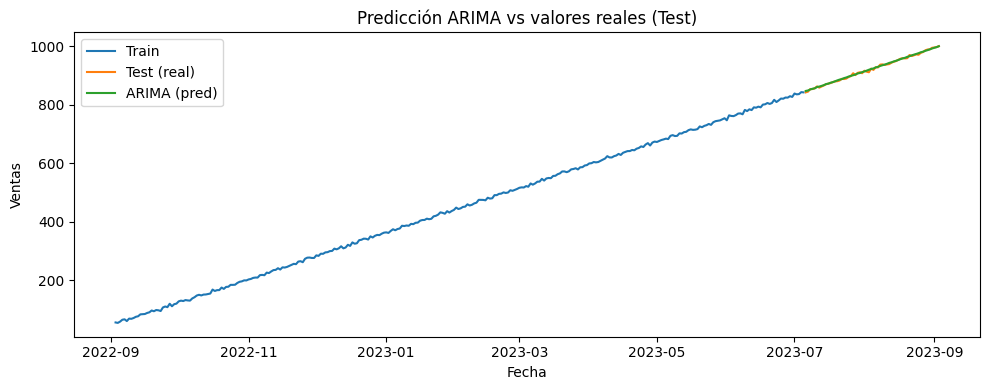

In [70]:
plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test (real)")
plt.plot(arima_pred, label="ARIMA (pred)")
plt.title("Predicción ARIMA vs valores reales (Test)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.tight_layout()
plt.show()


#### Compración de métricas

In [71]:
results = pd.DataFrame({"Modelo": ["Referencia", "ARIMA"],
                        "MAE": [mean_absolute_error(test, baseline_pred), mean_absolute_error(test, arima_pred)],
                        "RMSE": [rmse(test, baseline_pred), rmse(test, arima_pred)]}).sort_values("RMSE")
results

,Modelo,MAE,RMSE
1,ARIMA,2.219972,2.805048
0,Referencia,80.145631,92.123038


#### Conclusión 

La serie presenta una tendencia creciente muy marcada y, según Dickey-Fuller (p-value alto), es no estacionaria, por lo que un modelo ARIMA necesita gestionar esa tendencia mediante diferenciación.

En el conjunto de test, el modelo ARIMA ajusta muy bien los valores reales: la curva de predicción (verde) prácticamente se superpone a la del test (naranja). Esto se confirma en las métricas:

*Referencia: MAE = 80.15, RMSE = 92.12  
*ARIMA: MAE = 2.22, RMSE = 2.81  

ARIMA mejora claramente porque no asume un valor constante, sino que aprende la estructura temporal de la serie (tendencia y patrón semanal), aprovechando la autocorrelación observada. De esta manera reduce el error de forma drástica y se convierte en una herramienta fiable para estimar ventas futuras y dimensionar el almacén.


### Guardado del modelo

In [74]:
model_path = "../models/arima_sales_model.joblib"

joblib.dump(arima_model, model_path)
model_path


'../models/arima_sales_model.joblib'